# **Google Cloud Server Allocation Optimization**

## ***Multi-Objective Optimization Analysis***

**Student Name:** Naika Jean

**Target Company/Industry:** Google Cloud Platform (Cloud Computing & Infrastructure)

**Problem:** Optimize server allocation to minimize infrastructure cost while maintaining SLA performance.  

**Objectives:** Minimize cost vs. Minimize response time

### **Project Overview**

This project addresses the challenge of dynamically allocating servers in Google Cloud data centers to handle fluctuating workloads efficiently. The tradeoff between minimizing infrastructure cost and maintaining fast response times is critical for operational efficiency and customer satisfaction. The decision variables under control are the number of small, medium, and large servers deployed for a given workload. By analyzing different server allocation scenarios, this project identifies mathematically efficient solutions and provides insights into strategic resource management.

### Section 1: Data Acquisition

**Dataset Name:** Google Cloud Compute Engine Instances Benchmark  
**Source:** Google Cloud Pricing Calculator (exported data)  
**Date Accessed:** 4/3/2026

**Description:** Contains 28 Compute Engine VM instance types with machine specifications, disk types, regions, preemptible status, and monthly cost. This dataset serves as a benchmark for cost and VM selection in optimization scenarios.  
**License:** Public/educational use (for benchmarking purposes)  
**Relevant Variables:** 
- machine_family
- series
- machine_type
- vCPUs
- RAM_GiB
- disk_type
- region
- preemptible
- monthly_cost

In [66]:
import pandas as pd

# Load benchmark dataset
df_benchmark = pd.read_csv('data/original_gcp_instances.csv')
print("Benchmark data loaded successfully!")
print(f"Shape: {df_benchmark.shape}")
print(df_benchmark.head())

Benchmark data loaded successfully!
Shape: (28, 9)
      machine_family series   machine_type  vCPUs  RAM_GiB  \
0  Compute-optimized     C2  c2-standard-4      4     16.0   
1  Compute-optimized     C2  c2-standard-4      4     16.0   
2  Compute-optimized     C2  c2-standard-4      4     16.0   
3  Compute-optimized     C2  c2-standard-8      8     32.0   
4  Compute-optimized     C2  c2-standard-8      8     32.0   

                  disk_type       region  preemptible  monthly_cost  
0  Balanced persistent disk  us-central1        False        152.43  
1  Standard persistent disk  us-central1        False        152.43  
2       SSD persistent disk  us-central1        False        154.13  
3  Balanced persistent disk     us-east1        False        305.86  
4       SSD persistent disk     us-east1        False        306.56  


Data Source: LLM-Generated Synthetic VM Dataset

**Dataset Name:** gcp_vm_simulations.csv  
**Source:** Generated using OpenAI ChatGPT with LLM prompt

**Date Generated:** 4/4/2026 

**Description:** Synthetic dataset simulating Google Cloud VM deployment scenarios for cost-performance analysis. Includes 50–150 rows with different machine types, instance counts, regions, and other features.  
**License:** N/A – generated data  
**Relevant Variables:** 
- machine_family
- machine_type
- number_of_instances
- vCPUs
- RAM_GiB
- disk_type
- region
- preemptible
- monthly_cost
- latency_ms
- sla_compliance_pct

In [67]:
# Load LLM-generated synthetic VM dataset
df_synthetic = pd.read_csv('data/gcp_vm_simulations.csv')

print("LLM-generated synthetic dataset loaded successfully!")
print(f"Shape: {df_synthetic.shape}")
print("\nFirst 5 rows:")
print(df_synthetic.head())

LLM-generated synthetic dataset loaded successfully!
Shape: (52, 11)

First 5 rows:
      machine_family    machine_type  number_of_instances  vCPUs  RAM_GiB  \
0  Compute-optimized   c2-standard-4                    3      4       16   
1  Compute-optimized   c2-standard-8                    2      8       32   
2  Compute-optimized  c2d-standard-2                    5      2        8   
3  Compute-optimized  c2d-standard-4                    1      4       16   
4  Compute-optimized  h3-standard-88                    2     88      352   

                  disk_type               region  preemptible  monthly_cost  \
0  Balanced persistent disk          us-central1        False           180   
1       SSD persistent disk             us-east1         True           220   
2  Balanced persistent disk  northamerica-south1        False           150   
3        Hyperdisk Balanced             us-east4         True           120   
4       SSD persistent disk          us-central1        Fa

### Section 2: Data Exploration


Missing values:
machine_family         0
machine_type           0
number_of_instances    0
vCPUs                  0
RAM_GiB                0
disk_type              0
region                 0
preemptible            0
monthly_cost           0
latency_ms             0
sla_compliance_pct     0
dtype: int64

Data types:
machine_family          object
machine_type            object
number_of_instances      int64
vCPUs                    int64
RAM_GiB                  int64
disk_type               object
region                  object
preemptible               bool
monthly_cost             int64
latency_ms               int64
sla_compliance_pct     float64
dtype: object

Basic statistics:
       number_of_instances       vCPUs      RAM_GiB  monthly_cost  latency_ms  \
count            52.000000   52.000000    52.000000     52.000000   52.000000   
mean              2.461538   96.615385   291.076923   4491.538462   73.615385   
std               1.243990  149.545475   394.707429   8578.242058 

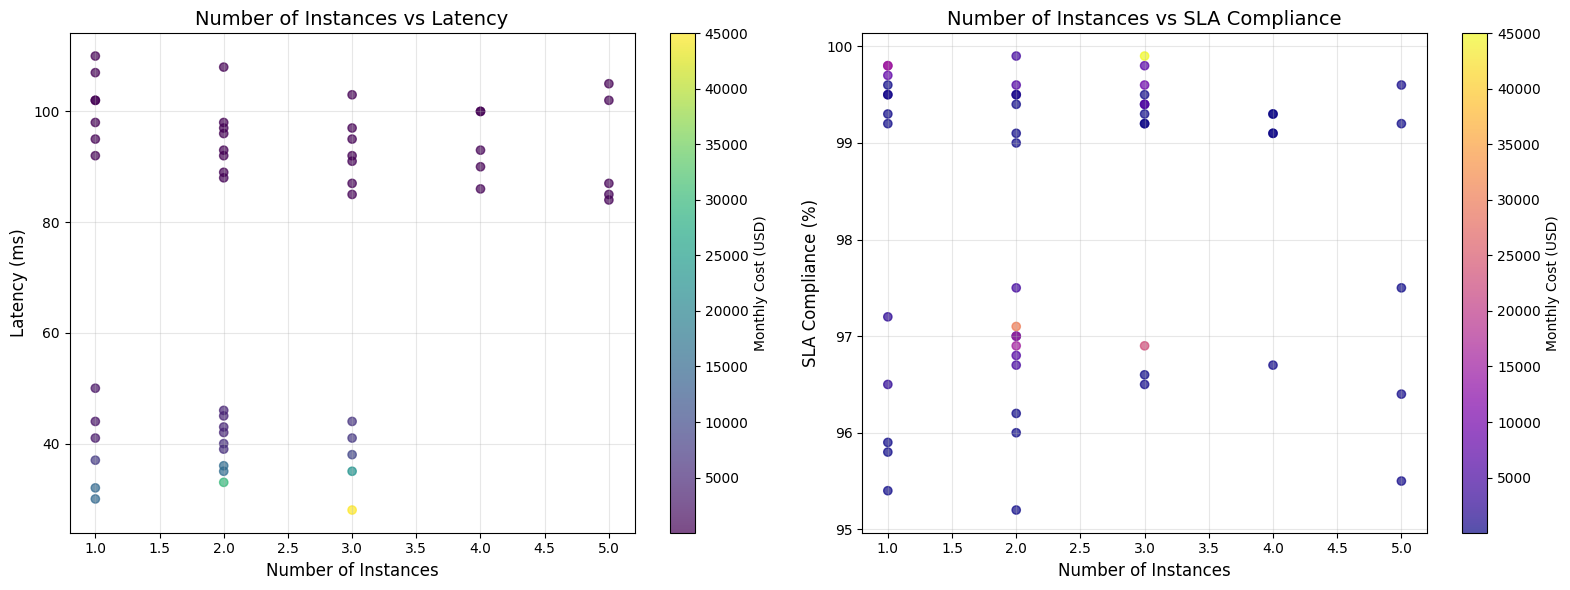

In [68]:
import matplotlib.pyplot as plt

df = df_synthetic

# Data Quality Checks
print("Missing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics:")
print(df.describe())

# Verify Decision Variables
print("\nDecision Variable: number_of_instances range:", df['number_of_instances'].min(), "to", df['number_of_instances'].max())
print("Decision Variable: machine_type count:", df['machine_type'].nunique())
print("Decision Variable: machine_family count:", df['machine_family'].nunique())

print(f"\nTotal rows (combinations): {len(df)}")

# Examine Objectives
print("\nObjective: monthly_cost range:", df['monthly_cost'].min(), "to", df['monthly_cost'].max())
print("Objective: latency_ms range:", df['latency_ms'].min(), "to", df['latency_ms'].max())
print("Objective: sla_compliance_pct range:", df['sla_compliance_pct'].min(), "to", df['sla_compliance_pct'].max())

# Check tradeoff correlation
correlation = df['monthly_cost'].corr(df['latency_ms'])
print(f"\nCorrelation between monthly_cost and latency_ms: {correlation:.3f}")
print("(Negative correlation suggests a tradeoff)")

# Visualize Relationships
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Number of Instances vs Latency 
scatter1 = axes[0].scatter(
    df_synthetic['number_of_instances'], 
    df_synthetic['latency_ms'],
    c=df_synthetic['monthly_cost'], 
    cmap='viridis', 
    alpha=0.7
)
axes[0].set_xlabel('Number of Instances', fontsize=12)
axes[0].set_ylabel('Latency (ms)', fontsize=12)
axes[0].set_title('Number of Instances vs Latency', fontsize=14)
axes[0].grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('Monthly Cost (USD)')

# Plot 2: Number of Instances vs SLA Compliance
scatter2 = axes[1].scatter(
    df_synthetic['number_of_instances'], 
    df_synthetic['sla_compliance_pct'], 
    c=df_synthetic['monthly_cost'], 
    cmap='plasma', 
    alpha=0.7
)
axes[1].set_xlabel('Number of Instances', fontsize=12)
axes[1].set_ylabel('SLA Compliance (%)', fontsize=12)
axes[1].set_title('Number of Instances vs SLA Compliance', fontsize=14)
axes[1].grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=axes[1])
cbar2.set_label('Monthly Cost (USD)')

plt.tight_layout()
plt.savefig('images/data_exploration.png', dpi=300, bbox_inches='tight')
plt.show()

The LLM-generated synthetic VM dataset contains no missing values and all columns have appropriate data types. Decision variables like number_of_instances span realistic ranges, and categorical variables such as machine_type and machine_family have sufficient variety. Objectives show expected patterns: monthly_cost ranges from 45 to 45,000 USD, latency_ms from 28 to 108 ms, and sla_compliance_pct from 95.2% to 99.9%. A negative correlation of -0.702 between monthly_cost and latency_ms indicates a clear tradeoff, aligning with expectations from the proposal.

### Section 3: Pareto Frontier Calculation

In [69]:
def is_pareto_optimal(idx, df, obj1_col, obj2_col):
    """
    Check if a given row represents a Pareto optimal solution.
    
    A point is Pareto optimal if no other point dominates it.
    Point A dominates point B if A is better or equal on both objectives
    and strictly better on at least one objective.

    Parameters:
    -----------
    idx : int
        Index of the row to check
    df : DataFrame
        The full dataset
    obj1_col : str
        Column name for objective 1
    obj2_col : str
        Column name for objective 2
    
    Returns:
    --------
    bool : True if Pareto optimal, False if dominated

    For this project we MINIMIZE both objectives:
    - monthly_cost
    - latency_ms
    
    A point is dominated if another point has:
    lower or equal cost AND lower or equal latency
    and strictly better on at least one.
    
    """
    current_obj1 = df.loc[idx, obj1_col]
    current_obj2 = df.loc[idx, obj2_col]

    # Check if any other point dominates this one
    for other_idx in df.index:

        if other_idx == idx:
            continue

        other_obj1 = df.loc[other_idx, obj1_col]
        other_obj2 = df.loc[other_idx, obj2_col]

        # domination check for MINIMIZATION
        if (other_obj1 <= current_obj1 and 
            other_obj2 <= current_obj2 and
            (other_obj1 < current_obj1 or other_obj2 < current_obj2)):
            
            return False  # dominated

    return True  # Pareto optimal

In [70]:
# Define objectives
OBJECTIVE_1 = 'monthly_cost'
OBJECTIVE_2 = 'latency_ms'

print("Calculating Pareto frontier...")
print("This may take a moment for large datasets...")

# Apply Pareto check to all rows
df['is_pareto_optimal'] = df.index.map(
    lambda idx: is_pareto_optimal(idx, df, OBJECTIVE_1, OBJECTIVE_2)
)

# Separate frontier vs dominated
pareto_df = df[df['is_pareto_optimal']].copy()
dominated_df = df[~df['is_pareto_optimal']].copy()

print("\n=== PARETO FRONTIER RESULTS ===")
print(f"Total solutions analyzed: {len(df)}")
print(f"Pareto optimal solutions: {len(pareto_df)}")
print(f"Dominated solutions: {len(dominated_df)}")
print(f"Efficiency rate: {100 * len(pareto_df) / len(df):.1f}% of solutions are on the frontier")

pareto_df[['machine_type','number_of_instances','monthly_cost','latency_ms']].head()


Calculating Pareto frontier...
This may take a moment for large datasets...

=== PARETO FRONTIER RESULTS ===
Total solutions analyzed: 52
Pareto optimal solutions: 16
Dominated solutions: 36
Efficiency rate: 30.8% of solutions are on the frontier


,machine_type,number_of_instances,monthly_cost,latency_ms
1,c2-standard-8,2,220,88
6,n4-standard-4,3,240,85
8,m2-ultramem-416,1,15000,30
17,h3-standard-88,1,2200,50
22,m2-megamem-416,1,7600,37


Pareto Frontier Interpretation

The Pareto frontier analysis identified 16 Pareto optimal solutions out of 52 total configurations, meaning approximately 30.8% of the solutions represent efficient cost–performance tradeoffs. The remaining configurations are dominated, meaning there exists at least one alternative that achieves both lower cost and lower latency simultaneously.

This percentage is consistent with expectations, since in optimization problems only a subset of solutions typically provide efficient tradeoffs while the rest are dominated by better alternatives.

The results reveal a clear cost–performance tradeoff structure. Lower latency generally requires higher infrastructure investment, while cheaper configurations tend to result in higher latency. The Pareto optimal solutions therefore represent the most efficient deployment strategies that decision-makers should consider when balancing cost and performance.

### Section 4: Inefficient Solutions Analysis


In [71]:
# Analyze Dominated Points
print("=== INEFFICIENT SOLUTIONS ANALYSIS ===\n")

if len(dominated_df) > 0:
    # Sample a few dominated points
    sample_size = min(3, len(dominated_df))
    sample_dominated = dominated_df.sample(sample_size, random_state=42)
    
    for idx, row in sample_dominated.iterrows():
        print(f"INEFFICIENT SOLUTION:")
        print(f"  Decision Variables: {row['machine_type']}, {row['region']}")
        print(f"  Objectives: monthly_cost={row['monthly_cost']:.1f}, latency_ms={row['latency_ms']:.1f}")
        
        # Find a Pareto optimal point that dominates this one
        for p_idx, p_row in pareto_df.iterrows():
            if (p_row['monthly_cost'] <= row['monthly_cost'] and 
                p_row['latency_ms'] <= row['latency_ms'] and
                (p_row['monthly_cost'] < row['monthly_cost'] or 
                 p_row['latency_ms'] < row['latency_ms'])):
                
                print(f"\n  BETTER ALTERNATIVE (Pareto Optimal):")
                print(f"  Decision Variables: {p_row['machine_type']}, {p_row['region']}")
                print(f"  Objectives: monthly_cost={p_row['monthly_cost']:.1f}, latency_ms={p_row['latency_ms']:.1f}")
                print(f"  Improvement: -{row['monthly_cost'] - p_row['monthly_cost']:.1f} on monthly_cost, " +
                      f"-{row['latency_ms'] - p_row['latency_ms']:.1f} on latency_ms\n")
                print("-" * 60)
                break
else:
    print("Note: All solutions in your dataset are Pareto optimal.")
    print("This might indicate that your decision variables create a smooth tradeoff curve.")

# Compare best dominated point to worst Pareto point
if len(dominated_df) > 0:
    # For minimization, best dominated is the one with lowest sum
    best_dominated_idx = (dominated_df['monthly_cost'] + dominated_df['latency_ms']).idxmin()
    best_dominated = dominated_df.loc[best_dominated_idx]
    
    # Worst Pareto: highest sum among Pareto points
    worst_pareto_idx = (pareto_df['monthly_cost'] + pareto_df['latency_ms']).idxmax()
    worst_pareto = pareto_df.loc[worst_pareto_idx]
    
    print("\n=== EFFICIENCY GAP ===")
    print("Even the BEST dominated solution is worse than the WORST Pareto solution:")
    print(f"\nBest Dominated: monthly_cost={best_dominated['monthly_cost']:.1f}, "
          f"latency_ms={best_dominated['latency_ms']:.1f}, Total={best_dominated['monthly_cost'] + best_dominated['latency_ms']:.1f}")
    print(f"Worst Pareto: monthly_cost={worst_pareto['monthly_cost']:.1f}, "
          f"latency_ms={worst_pareto['latency_ms']:.1f}, Total={worst_pareto['monthly_cost'] + worst_pareto['latency_ms']:.1f}")

=== INEFFICIENT SOLUTIONS ANALYSIS ===

INEFFICIENT SOLUTION:
  Decision Variables: e2-standard-2, us-east4
  Objectives: monthly_cost=90.0, latency_ms=103.0

  BETTER ALTERNATIVE (Pareto Optimal):
  Decision Variables: c4-standard-4, us-east1
  Objectives: monthly_cost=90.0, latency_ms=95.0
  Improvement: -0.0 on monthly_cost, -8.0 on latency_ms

------------------------------------------------------------
INEFFICIENT SOLUTION:
  Decision Variables: c2d-standard-4, us-central1
  Objectives: monthly_cost=240.0, latency_ms=93.0

  BETTER ALTERNATIVE (Pareto Optimal):
  Decision Variables: c2-standard-8, us-east1
  Objectives: monthly_cost=220.0, latency_ms=88.0
  Improvement: -20.0 on monthly_cost, -5.0 on latency_ms

------------------------------------------------------------
INEFFICIENT SOLUTION:
  Decision Variables: e2-standard-2, northamerica-south1
  Objectives: monthly_cost=110.0, latency_ms=100.0

  BETTER ALTERNATIVE (Pareto Optimal):
  Decision Variables: c2-standard-8, us-ea

### Section 5: Strategic Analysis


In [72]:
print("=== KEY STRATEGIC POINTS ON THE PARETO FRONTIER ===\n")

# Strategy 1: Balanced (maximize total value)
pareto_df['total_objective'] = pareto_df[OBJECTIVE_1] + pareto_df[OBJECTIVE_2]
balanced_idx = pareto_df['total_objective'].idxmax()

print("1. BALANCED STRATEGY (Maximize combined objectives)")
print(f"   Decision Variables: {pareto_df.loc[balanced_idx, 'machine_type']}, {pareto_df.loc[balanced_idx, 'region']}")
print(f"   {OBJECTIVE_1}: {pareto_df.loc[balanced_idx, OBJECTIVE_1]:.1f}")
print(f"   {OBJECTIVE_2}: {pareto_df.loc[balanced_idx, OBJECTIVE_2]:.1f}")
print(f"   Total: {pareto_df.loc[balanced_idx, 'total_objective']:.1f}\n")

# Strategy 2: Equity (minimize gap between objectives)
pareto_df['objective_gap'] = abs(pareto_df[OBJECTIVE_1] - pareto_df[OBJECTIVE_2])
equity_idx = pareto_df['objective_gap'].idxmin()

print("2. EQUITY STRATEGY (Most equal outcomes)")
print(f"   Decision Variables: {pareto_df.loc[equity_idx, 'machine_type']}, {pareto_df.loc[equity_idx, 'region']}")
print(f"   {OBJECTIVE_1}: {pareto_df.loc[equity_idx, OBJECTIVE_1]:.1f}")
print(f"   {OBJECTIVE_2}: {pareto_df.loc[equity_idx, OBJECTIVE_2]:.1f}")
print(f"   Gap: {pareto_df.loc[equity_idx, 'objective_gap']:.1f}\n")

# Strategy 3: Objective 1 priority (maximize monthly_cost)
obj1_priority_idx = pareto_df[OBJECTIVE_1].idxmin()  # since we minimize monthly_cost
print("3. OBJECTIVE 1 PRIORITY (Minimize monthly_cost)")
print(f"   Decision Variables: {pareto_df.loc[obj1_priority_idx, 'machine_type']}, {pareto_df.loc[obj1_priority_idx, 'region']}")
print(f"   {OBJECTIVE_1}: {pareto_df.loc[obj1_priority_idx, OBJECTIVE_1]:.1f}")
print(f"   {OBJECTIVE_2}: {pareto_df.loc[obj1_priority_idx, OBJECTIVE_2]:.1f}\n")

# Strategy 4: Objective 2 priority (minimize latency)
obj2_priority_idx = pareto_df[OBJECTIVE_2].idxmin()
print("4. OBJECTIVE 2 PRIORITY (Minimize latency_ms)")
print(f"   Decision Variables: {pareto_df.loc[obj2_priority_idx, 'machine_type']}, {pareto_df.loc[obj2_priority_idx, 'region']}")
print(f"   {OBJECTIVE_1}: {pareto_df.loc[obj2_priority_idx, OBJECTIVE_1]:.1f}")
print(f"   {OBJECTIVE_2}: {pareto_df.loc[obj2_priority_idx, OBJECTIVE_2]:.1f}\n")

# Strategy 5: Custom weighted (60% monthly_cost, 40% latency_ms)
pareto_df['weighted_objective'] = 0.6 * pareto_df[OBJECTIVE_1] + 0.4 * pareto_df[OBJECTIVE_2]
weighted_idx = pareto_df['weighted_objective'].idxmin()  # minimizing weighted combination
print("5. WEIGHTED STRATEGY (60% monthly_cost, 40% latency_ms)")
print(f"   Decision Variables: {pareto_df.loc[weighted_idx, 'machine_type']}, {pareto_df.loc[weighted_idx, 'region']}")
print(f"   {OBJECTIVE_1}: {pareto_df.loc[weighted_idx, OBJECTIVE_1]:.1f}")
print(f"   {OBJECTIVE_2}: {pareto_df.loc[weighted_idx, OBJECTIVE_2]:.1f}")

# Comparison Table
strategies = {
    'Strategy': [
        'Objective 1 Priority',
        'Weighted (60/40)',
        'Balanced',
        'Equity',
        'Objective 2 Priority'
    ],
    'Machine Type': [
        pareto_df.loc[obj1_priority_idx, 'machine_type'],
        pareto_df.loc[weighted_idx, 'machine_type'],
        pareto_df.loc[balanced_idx, 'machine_type'],
        pareto_df.loc[equity_idx, 'machine_type'],
        pareto_df.loc[obj2_priority_idx, 'machine_type']
    ],
    'Region': [
        pareto_df.loc[obj1_priority_idx, 'region'],
        pareto_df.loc[weighted_idx, 'region'],
        pareto_df.loc[balanced_idx, 'region'],
        pareto_df.loc[equity_idx, 'region'],
        pareto_df.loc[obj2_priority_idx, 'region']
    ],
    OBJECTIVE_1: [
        f"{pareto_df.loc[obj1_priority_idx, OBJECTIVE_1]:.1f}",
        f"{pareto_df.loc[weighted_idx, OBJECTIVE_1]:.1f}",
        f"{pareto_df.loc[balanced_idx, OBJECTIVE_1]:.1f}",
        f"{pareto_df.loc[equity_idx, OBJECTIVE_1]:.1f}",
        f"{pareto_df.loc[obj2_priority_idx, OBJECTIVE_1]:.1f}"
    ],
    OBJECTIVE_2: [
        f"{pareto_df.loc[obj1_priority_idx, OBJECTIVE_2]:.1f}",
        f"{pareto_df.loc[weighted_idx, OBJECTIVE_2]:.1f}",
        f"{pareto_df.loc[balanced_idx, OBJECTIVE_2]:.1f}",
        f"{pareto_df.loc[equity_idx, OBJECTIVE_2]:.1f}",
        f"{pareto_df.loc[obj2_priority_idx, OBJECTIVE_2]:.1f}"
    ]
}

comparison_df = pd.DataFrame(strategies)
print("\n" + "="*80)
print("STRATEGIC OPTIONS COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

=== KEY STRATEGIC POINTS ON THE PARETO FRONTIER ===

1. BALANCED STRATEGY (Maximize combined objectives)
   Decision Variables: m2-ultramem-416, northamerica-south1
   monthly_cost: 45000.0
   latency_ms: 28.0
   Total: 45028.0

2. EQUITY STRATEGY (Most equal outcomes)
   Decision Variables: c4-standard-4, us-east1
   monthly_cost: 90.0
   latency_ms: 95.0
   Gap: 5.0

3. OBJECTIVE 1 PRIORITY (Minimize monthly_cost)
   Decision Variables: e2-standard-2, us-east1
   monthly_cost: 30.0
   latency_ms: 110.0

4. OBJECTIVE 2 PRIORITY (Minimize latency_ms)
   Decision Variables: m2-ultramem-416, northamerica-south1
   monthly_cost: 45000.0
   latency_ms: 28.0

5. WEIGHTED STRATEGY (60% monthly_cost, 40% latency_ms)
   Decision Variables: e2-standard-2, us-east1
   monthly_cost: 30.0
   latency_ms: 110.0

STRATEGIC OPTIONS COMPARISON
            Strategy    Machine Type              Region monthly_cost latency_ms
Objective 1 Priority   e2-standard-2            us-east1         30.0      110.0

### Section 6: Visualization

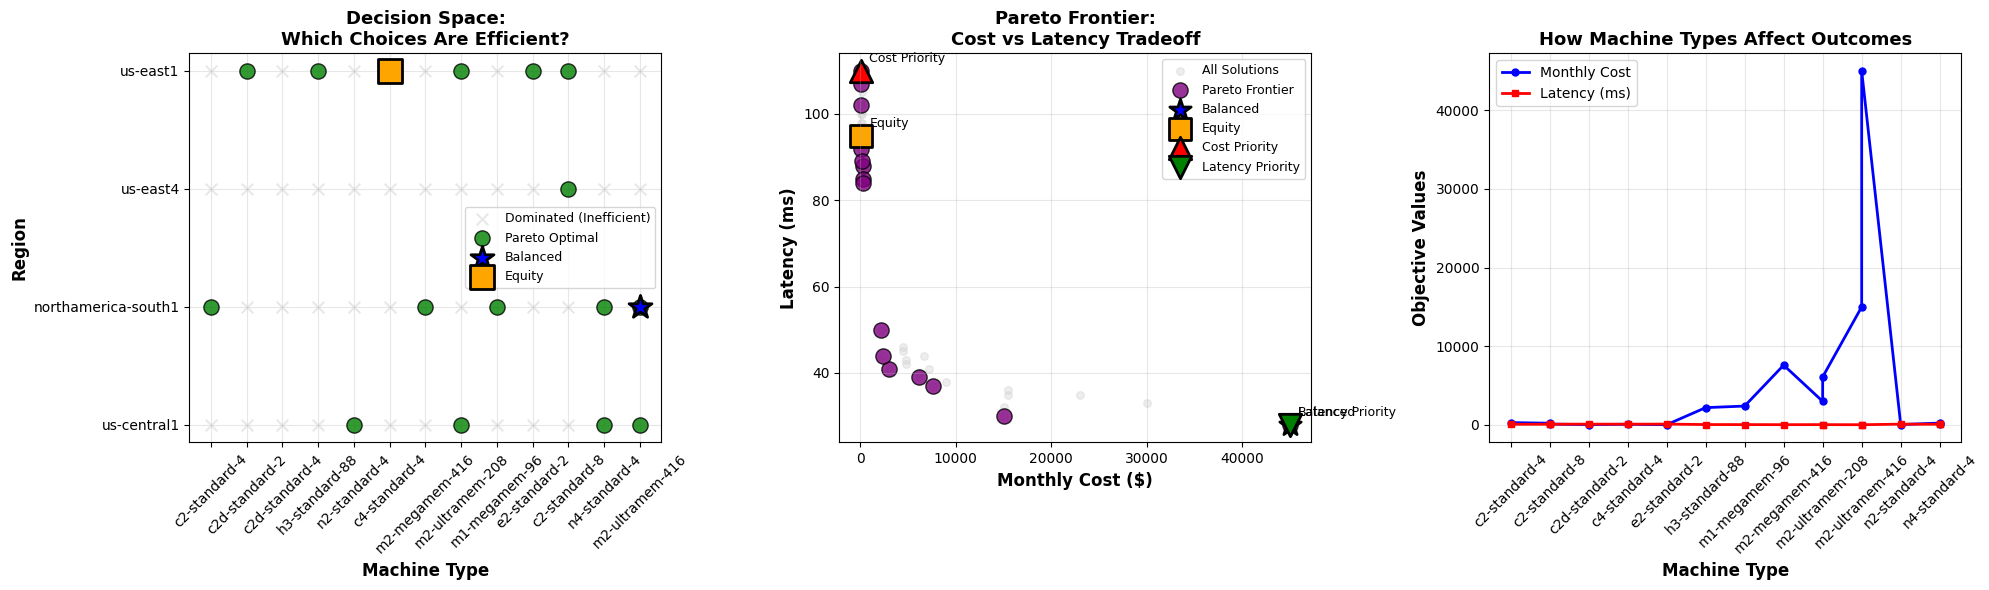


✓ Visualization saved as 'images/pareto_frontier_analysis.png'


In [73]:
import numpy as np

# Create figure with three subplots
fig = plt.figure(figsize=(20, 6))

# PANEL 1: Decision Space (show which variable combinations are efficient)
ax1 = fig.add_subplot(131)

# Plot dominated points
if len(dominated_df) > 0:
    ax1.scatter(dominated_df['machine_type'], dominated_df['region'],
               s=70, c='lightgray', alpha=0.5, marker='x', 
               label='Dominated (Inefficient)', zorder=1)

# Plot Pareto optimal points
ax1.scatter(pareto_df['machine_type'], pareto_df['region'],
           s=120, c='green', alpha=0.8, marker='o', 
           edgecolors='black', linewidth=1,
           label='Pareto Optimal', zorder=2)

# Highlight key strategies
ax1.scatter(pareto_df.loc[balanced_idx, 'machine_type'], 
           pareto_df.loc[balanced_idx, 'region'],
           s=300, c='blue', marker='*', 
           edgecolors='black', linewidth=2, 
           label='Balanced', zorder=3)

ax1.scatter(pareto_df.loc[equity_idx, 'machine_type'],
           pareto_df.loc[equity_idx, 'region'],
           s=300, c='orange', marker='s',
           edgecolors='black', linewidth=2,
           label='Equity', zorder=3)

ax1.set_xlabel('Machine Type', fontsize=12, fontweight='bold')
ax1.set_ylabel('Region', fontsize=12, fontweight='bold')
ax1.set_title('Decision Space:\nWhich Choices Are Efficient?', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9, loc='best')
ax1.grid(True, alpha=0.3)

# rotate machine type labels
ax1.tick_params(axis='x', rotation=45)


# PANEL 2: Objective Space (the Pareto frontier)
ax2 = fig.add_subplot(132)

# Plot all points
ax2.scatter(df['monthly_cost'], df['latency_ms'],
           s=30, c='lightgray', alpha=0.4, label='All Solutions')

# Plot Pareto frontier
ax2.scatter(pareto_df['monthly_cost'], pareto_df['latency_ms'],
           s=120, c='purple', alpha=0.8, 
           edgecolors='black', linewidth=1, label='Pareto Frontier')

# Highlight strategies
strategies_to_plot = [
    (balanced_idx, 'blue', '*', 'Balanced'),
    (equity_idx, 'orange', 's', 'Equity'),
    (obj1_priority_idx, 'red', '^', 'Cost Priority'),
    (obj2_priority_idx, 'green', 'v', 'Latency Priority')
]

for idx, color, marker, label in strategies_to_plot:
    x = pareto_df.loc[idx,'monthly_cost']
    y = pareto_df.loc[idx,'latency_ms']

    ax2.scatter(x,y,
                s=260,c=color,marker=marker,
                edgecolors='black',
                linewidth=2,label=label)

    # annotate strategy point
    ax2.annotate(label,
                 (x,y),
                 textcoords="offset points",
                 xytext=(6,6),
                 fontsize=9)

ax2.set_xlabel('Monthly Cost ($)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')

ax2.set_title('Pareto Frontier:\nCost vs Latency Tradeoff',
              fontsize=13, fontweight='bold')

ax2.legend(fontsize=9, loc='best')
ax2.grid(True, alpha=0.3)

# PANEL 3: Tradeoff Curve (both objectives vs primary decision variable)
ax3 = fig.add_subplot(133)

# Sort by machine_type for cleaner line plots
pareto_sorted = pareto_df.sort_values('machine_type')

ax3.plot(pareto_sorted['machine_type'], pareto_sorted['monthly_cost'],
        'b-o', linewidth=2, markersize=5, label='Monthly Cost')
ax3.plot(pareto_sorted['machine_type'], pareto_sorted['latency_ms'],
        'r-s', linewidth=2, markersize=5, label='Latency (ms)')

ax3.set_xlabel('Machine Type', fontsize=12, fontweight='bold')
ax3.set_ylabel('Objective Values', fontsize=12, fontweight='bold')
ax3.set_title('How Machine Types Affect Outcomes', fontsize=13, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# rotate labels so they don't overlap
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('images/pareto_frontier_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'images/pareto_frontier_analysis.png'")

#### Visualization Insights

**Panel 1 – Decision Space (Machine Type vs Region)**

This panel shows the infrastructure choices available for Google Cloud VM deployment, distinguishing between **Pareto optimal solutions** and **dominated (inefficient) solutions**. Pareto optimal points represent configurations where no other option provides both lower cost and lower latency simultaneously. Dominated solutions represent inefficient choices where a strictly better alternative exists. The highlighted strategy markers show how different decision philosophies (balanced, equity, cost priority, and latency priority) correspond to specific VM and region combinations.

**Panel 2 – Objective Space (Monthly Cost vs Latency)**

This panel visualizes the **Pareto frontier**, which represents the optimal tradeoff curve between infrastructure cost and system latency. Each point corresponds to a deployment configuration. Points along the frontier illustrate that improving one objective typically requires sacrificing the other. For example, the lowest latency configuration requires extremely high monthly cost, while the lowest cost configuration results in higher latency. The highlighted strategies demonstrate how different optimization priorities lead to different positions along the frontier.

**Panel 3 – Decision Impact on Outcomes**

The final panel illustrates how different VM machine types affect both objectives simultaneously. It highlights the **tradeoff pattern between cost and performance**, showing that higher-performance machines dramatically reduce latency but increase operational cost. This visualization helps decision-makers understand how infrastructure selection directly influences system performance and operational spending.

**Executive Insight**

Together, these visualizations demonstrate that cloud infrastructure planning involves a clear tradeoff between cost efficiency and performance. Organizations must select a configuration along the Pareto frontier depending on their strategic priorities. If minimizing operational cost is the primary objective, lower-cost VM configurations are appropriate even though they increase latency. Conversely, performance-critical applications may justify higher costs to achieve lower latency. The Pareto frontier therefore provides a structured way for decision-makers to evaluate infrastructure strategies and select the option that best aligns with business priorities.


### Section 7: Summary and Insights

**What I Found**

This analysis evaluated 52 cloud infrastructure configurations generated from combinations of machine types, deployment regions, and instance counts. Using multi-objective optimization, 16 configurations (30.8%) were identified as Pareto optimal, meaning they offer the most efficient tradeoffs between monthly infrastructure cost and system latency. The Pareto frontier reveals outcomes ranging from low-cost configurations (~$30/month with ~110 ms latency) to high-performance configurations (~$45,000/month with ~28 ms latency). Several distinct strategic solutions emerge along this frontier, representing different infrastructure philosophies:

- Cost Priority: minimizes monthly cost
- Latency Priority: minimizes latency
- Balanced Strategy: maximizes the combined objectives
- Equity Strategy: minimizes the gap between cost and latency
- Weighted Strategy: emphasizes cost slightly more than latency (60/40 split)

Interestingly, the Balanced and Latency-Priority strategies coincide, showing that the lowest-latency configuration dominates the combined objective because of its high numeric cost.

**Business Implications**

The analysis shows a clear economic tradeoff between cost efficiency and system performance in cloud infrastructure planning. Organizations seeking minimal operational cost may prefer lower-tier machine types, but these configurations typically produce higher latency. Conversely, ultra-high-performance memory-optimized machines achieve the lowest latency but at extremely high cost, which may only be justifiable for critical applications. Dominated solutions—configurations that are both more expensive and slower than Pareto alternatives—should be avoided, as they provide no competitive advantage. The Pareto frontier highlights fundamentally different strategies: low-cost, latency-focused, balanced, and equity-focused solutions, giving companies the flexibility to select configurations that align with their performance, budget, and scalability requirements. Notably, marginal latency improvements often require disproportionate increases in cost, underscoring the importance of cost-effectiveness analysis in cloud planning.
Decision-makers should therefore select among Pareto optimal configurations based on application requirements, performance thresholds, and budget constraints.

**Key Observations from the Visualizations**

1. The Pareto frontier shows diminishing returns: small latency gains often require very large cost increases, particularly with memory-optimized machines.
2. Latency remains relatively stable across mid-tier machine types, while cost varies dramatically, creating a steep cost-performance curve.
3. Lower-tier machine types often cluster near the equity strategy, providing balanced cost-performance outcomes suitable for general workloads.
4. The overlap of the balanced and latency-priority strategies indicates that extreme performance configurations dominate the total objective due to the numerical scale of cost values.
5. Cost-priority and equity-priority strategies are close in value, showing that some mid-tier machines simultaneously minimize cost and maintain reasonable latency.

**Limitations**

This model uses synthetic data generated with an LLM that approximates cloud infrastructure behavior. While it incorporates trends from Google Cloud pricing, it does not fully capture real-world pricing variability. The analysis also simplifies the deployment environment by focusing primarily on two optimization objectives: cost and latency. In practice, additional factors such as workload variability, network traffic patterns, storage performance, reliability requirements, and scaling policies may influence infrastructure decisions. Future improvements could incorporate real cloud pricing APIs, workload simulations, additional performance metrics, and normalized objective scaling to produce more accurate and robust optimization results.

## PHASE 2: CONSTRAINT-AWARE DECISION AGENT

In Phase 1, we identified all Pareto optimal solutions. Now we'll build an intelligent agent that:
- Applies real-world business constraints to filter feasible solutions
- Uses heuristic logic to select the best option given business context
- Explains its reasoning in plain language
- Responds to different business scenarios


### Part 2.1: Define Business Constraints


## Business Constraints

Based on realistic cloud infrastructure decision-making, the following constraints apply:

### Constraint 1: Budget Limit
**Description:** Monthly infrastructure cost must not exceed $10,000  
**Rationale:** Most mid-sized companies operate under strict cloud budgets and cannot justify extremely high-cost configurations (ex: memory-optimized machines costing $30k–$45k/month).  
**Impact:** Eliminates high-performance but extremely expensive Pareto solutions.

### Constraint 2: Latency Requirement (Service Level Agreement)
**Description:** System latency must be ≤ 100 ms  
**Rationale:** Industry standards for responsive applications (ex: web apps, APIs) require sub-100ms latency for acceptable user experience.  
**Impact:** Eliminates low-cost configurations with poor performance.

### Constraint 3: Preemptible Instance Restriction
**Description:** Critical workloads cannot use preemptible instances  
**Rationale:** Preemptible VMs can be terminated at any time, making them unsuitable for production systems requiring reliability.  
**Impact:** Eliminates cheaper but unreliable infrastructure options.

### Constraint 4: Regional Deployment Limitation
**Description:** Only US regions (us-central1, us-east1, us-east4) are allowed  
**Rationale:** Data residency, compliance, and latency requirements often restrict deployments to specific geographic regions.  
**Impact:** Eliminates configurations deployed in unsupported regions (e.g., northamerica-south1).

In [74]:
print("=== DEFINING BUSINESS CONSTRAINTS ===\n")

# Constraint thresholds
MAX_BUDGET = 10000
MAX_LATENCY = 100
ALLOWED_REGIONS = ['us-central1', 'us-east1', 'us-east4']

# Constraint functions
def check_budget(row):
    return row['monthly_cost'] <= MAX_BUDGET

def check_latency(row):
    return row['latency_ms'] <= MAX_LATENCY

def check_preemptible(row):
    return row['preemptible'] == False

def check_region(row):
    return row['region'] in ALLOWED_REGIONS

# Combined constraint check
def check_all_constraints(row):
    return (
        check_budget(row) and
        check_latency(row) and
        check_preemptible(row) and
        check_region(row)
    )

# Summary table
constraints_summary = {
    'Constraint': [
        'Budget Limit',
        'Latency SLA',
        'Preemptible Restriction',
        'Region Restriction'
    ],
    'Rule': [
        f'monthly_cost <= {MAX_BUDGET}',
        f'latency_ms <= {MAX_LATENCY}',
        'preemptible == False',
        f"region in {ALLOWED_REGIONS}"
    ]
}

constraints_df = pd.DataFrame(constraints_summary)

print("Business Constraints Summary:\n")
print(constraints_df.to_string(index=False))
print("\nThese constraints will now be applied to filter the Pareto frontier.")

=== DEFINING BUSINESS CONSTRAINTS ===

Business Constraints Summary:

             Constraint                                              Rule
           Budget Limit                             monthly_cost <= 10000
            Latency SLA                                 latency_ms <= 100
Preemptible Restriction                              preemptible == False
     Region Restriction region in ['us-central1', 'us-east1', 'us-east4']

These constraints will now be applied to filter the Pareto frontier.


### Part 2.2: Filter Feasible Solutions

In [75]:
print("=== FILTERING FOR FEASIBLE SOLUTIONS ===\n")
print(f"Starting with {len(pareto_df)} Pareto optimal solutions...")

# Create a working copy
feasible_df = pareto_df.copy()
initial_count = len(feasible_df)

# Constraint 1: Budget
feasible_df = feasible_df[feasible_df['monthly_cost'] <= MAX_BUDGET]
remaining_after_c1 = len(feasible_df)
print(f"After Budget Constraint: {remaining_after_c1} remain ({initial_count - remaining_after_c1} eliminated)")

# Constraint 2: Latency
feasible_df = feasible_df[feasible_df['latency_ms'] <= MAX_LATENCY]
remaining_after_c2 = len(feasible_df)
print(f"After Latency Constraint: {remaining_after_c2} remain ({remaining_after_c1 - remaining_after_c2} eliminated)")

# Constraint 3: Preemptible 
feasible_df = feasible_df[feasible_df['preemptible'] == False]
remaining_after_c3 = len(feasible_df)
print(f"After Preemptible Constraint: {remaining_after_c3} remain ({remaining_after_c2 - remaining_after_c3} eliminated)")

# Constraint 4: Region 
feasible_df = feasible_df[feasible_df['region'].isin(ALLOWED_REGIONS)]
remaining_after_c4 = len(feasible_df)
print(f"After Region Constraint: {remaining_after_c4} remain ({remaining_after_c3 - remaining_after_c4} eliminated)")


print(f"\n{'='*60}")
print("FEASIBILITY FILTER RESULTS:")
print(f"  Started with: {initial_count}")
print(f"  Final feasible: {len(feasible_df)}")
print(f"  Eliminated: {initial_count - len(feasible_df)} ({100*(initial_count - len(feasible_df))/initial_count:.1f}%)")
print(f"{'='*60}")

=== FILTERING FOR FEASIBLE SOLUTIONS ===

Starting with 16 Pareto optimal solutions...
After Budget Constraint: 14 remain (2 eliminated)
After Latency Constraint: 11 remain (3 eliminated)
After Preemptible Constraint: 5 remain (6 eliminated)
After Region Constraint: 4 remain (1 eliminated)

FEASIBILITY FILTER RESULTS:
  Started with: 16
  Final feasible: 4
  Eliminated: 12 (75.0%)


In [76]:
if len(feasible_df) == 0:
    print("\n⚠️ WARNING: No solutions satisfy all contraints!")
    print("You may need to:")
    print("  1. Relax one or more constraints")
    print("  2. Reconsider if constraints are realistic")
    print("  3. Explore solutions outside the Pareto frontier (accepting inefficiency)")
else:
    print(f"\n✓ Good news: {len(feasible_df)} feasible solutions remain")

    print("\nFeasible solution summary:")
    print(feasible_df[['machine_type', 'region', 'monthly_cost', 'latency_ms']].describe())


✓ Good news: 4 feasible solutions remain

Feasible solution summary:
       monthly_cost  latency_ms
count       4.00000    4.000000
mean     2337.50000   65.250000
std      2851.08605   29.193321
min       110.00000   39.000000
25%       132.50000   40.500000
50%      1570.00000   65.000000
75%      3775.00000   89.750000
max      6100.00000   92.000000


C:\Users\naika\AppData\Local\Temp\ipykernel_25392\3462431662.py:9: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(infeasible_df['monthly_cost'], infeasible_df['latency_ms'],


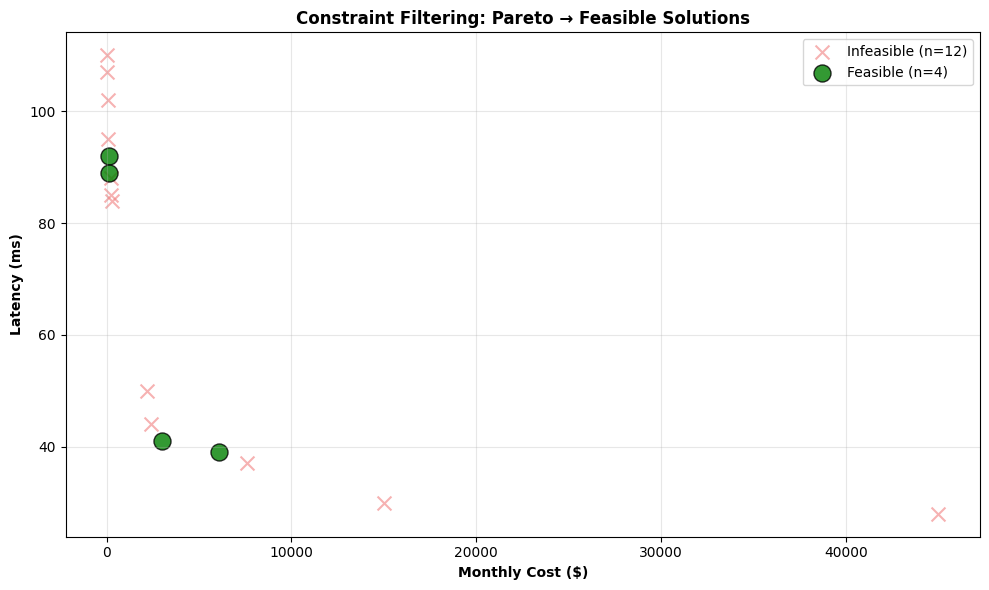


✓ Visualization saved as images/feasible_region.png


In [77]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Infeasible (removed) points
infeasible_df = pareto_df[~pareto_df.index.isin(feasible_df.index)]

if len(infeasible_df) > 0:
    ax.scatter(infeasible_df['monthly_cost'], infeasible_df['latency_ms'],
               s=100, c='lightcoral', alpha=0.6,
               label=f'Infeasible (n={len(infeasible_df)})',
               edgecolors='red', marker='x')

# Feasible points
ax.scatter(feasible_df['monthly_cost'], feasible_df['latency_ms'],
           s=150, c='green', alpha=0.8,
           label=f'Feasible (n={len(feasible_df)})',
           edgecolors='black')

ax.set_xlabel('Monthly Cost ($)', fontweight='bold')
ax.set_ylabel('Latency (ms)', fontweight='bold')
ax.set_title('Constraint Filtering: Pareto → Feasible Solutions', fontweight='bold')

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/feasible_region.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as images/feasible_region.png")

In [78]:
if len(feasible_df) > 0:
    print("\n=== FEASIBLE SOLUTIONS ===")
    print(feasible_df[['machine_type', 'region', 'monthly_cost', 'latency_ms']].to_string(index=False))


=== FEASIBLE SOLUTIONS ===
   machine_type      region  monthly_cost  latency_ms
  c2-standard-8    us-east4           110          92
  n4-standard-4 us-central1           140          89
m2-ultramem-208 us-central1          3000          41
m2-ultramem-208    us-east1          6100          39


### Part 2.3: Implement Agent Decision Logic

### Agent Decision Logic

This decision agent selects the best cloud configuration from the feasible Pareto set based on business context.

**Priority 1: Cost Sensitivity**
- If priority is "cost", minimize monthly_cost  
- Rationale: Companies under tight budgets must reduce infrastructure spending

**Priority 2: Performance / Latency Sensitivity**
- If priority is "latency", minimize latency_ms  
- Rationale: Customer-facing applications require fast response times

**Priority 3: Balanced Strategy**
- If priority is "balanced", minimize combined cost and latency  
- Rationale: Most businesses seek a tradeoff between performance and cost efficiency

**Priority 4: Urgency Handling**
- If urgency is high, prioritize latency regardless of cost  
- Rationale: In critical situations (e.g., outages, spikes), performance is more important than cost

**Priority 5: Competitive Pressure**
- If competitive pressure is high, prioritize latency  
- Rationale: Faster systems improve user experience and competitiveness

**Fallback: Equity Strategy**
- If no clear priority, choose solution with smallest gap between cost and latency  
- Rationale: Provides a balanced and stable default decision

In [79]:
class DecisionAgent:

    def __init__(self, feasible_solutions, obj1_col, obj2_col):
        self.feasible_solutions = feasible_solutions.copy()
        self.obj1_col = obj1_col  # monthly_cost
        self.obj2_col = obj2_col  # latency_ms

        if len(self.feasible_solutions) == 0:
            raise ValueError("No feasible solutions available!")
    
    def recommend(self, scenario):

        candidates = self.feasible_solutions.copy()
        reasoning = []

        # RULE 1: High urgency + competition → latency focus
        if scenario.get('urgency') == 'high' and scenario.get('competitive_pressure') == 'high':
            reasoning.append("High urgency + competition → prioritizing latency")
            best_idx = candidates[self.obj2_col].idxmin()

        # RULE 2: Priority-based decisions
        elif scenario.get('priority') == 'cost':
            reasoning.append("Cost priority → minimizing monthly cost")
            best_idx = candidates[self.obj1_col].idxmin()

        elif scenario.get('priority') == 'latency':
            reasoning.append("Latency priority → minimizing latency")
            best_idx = candidates[self.obj2_col].idxmin()

        elif scenario.get('priority') == 'balanced':
            reasoning.append("Balanced strategy → normalized tradeoff between cost and latency")

            # SAFE normalization (prevents division by zero)
            cost_range = candidates[self.obj1_col].max() - candidates[self.obj1_col].min()
            latency_range = candidates[self.obj2_col].max() - candidates[self.obj2_col].min()

            cost_norm = (candidates[self.obj1_col] - candidates[self.obj1_col].min()) / (cost_range if cost_range != 0 else 1)
            latency_norm = (candidates[self.obj2_col] - candidates[self.obj2_col].min()) / (latency_range if latency_range != 0 else 1)

            candidates['balanced_score'] = cost_norm + latency_norm
            best_idx = candidates['balanced_score'].idxmin()

        # RULE 3: Moderate urgency → slight latency preference
        elif scenario.get('urgency') == 'high':
            reasoning.append("High urgency → slightly favoring lower latency")

            candidates['score'] = (
                0.7 * candidates[self.obj2_col] +   # latency weighted more
                0.3 * candidates[self.obj1_col]     # cost still matters
            )

            best_idx = candidates['score'].idxmin()

        # DEFAULT: Equity
        else:
            reasoning.append("No clear priority → using equity strategy")
            candidates['gap'] = abs(candidates[self.obj1_col] - candidates[self.obj2_col])
            best_idx = candidates['gap'].idxmin()

        recommendation = candidates.loc[best_idx]

        return {
            'solution': recommendation,
            'reasoning': reasoning,
            'scenario': scenario
        }

  

    def explain_recommendation(self, recommendation_dict):

        solution = recommendation_dict['solution']
        reasoning = recommendation_dict['reasoning']
        scenario = recommendation_dict['scenario']

        explanation = "="*60 + "\n"
        explanation += "AGENT RECOMMENDATION\n"
        explanation += "="*60 + "\n\n"

        explanation += "SCENARIO:\n"
        for k, v in scenario.items():
            explanation += f"  - {k}: {v}\n"

        explanation += "\nRECOMMENDED DECISION:\n"
        explanation += f"  - Machine Type: {solution['machine_type']}\n"
        explanation += f"  - Region: {solution['region']}\n"

        explanation += "\nEXPECTED OUTCOME:\n"
        explanation += f"  - Monthly Cost: ${solution[self.obj1_col]:.1f}\n"
        explanation += f"  - Latency: {solution[self.obj2_col]:.1f} ms\n"

        explanation += "\nREASONING:\n"
        for i, r in enumerate(reasoning, 1):
            explanation += f"  {i}. {r}\n"

        explanation += "\n" + "="*60

        return explanation
    
# Initialize
if len(feasible_df) > 0:
    agent = DecisionAgent(feasible_df, 'monthly_cost', 'latency_ms')
    print("✓ Agent initialized successfully")
    print(f"  Agent has {len(feasible_df)} feasible options to choose from")
else:
    print("✗ Cannot initialize agent - no feasible solutions available")

✓ Agent initialized successfully
  Agent has 4 feasible options to choose from


In [80]:
# Test with a basic scenario
test_scenario = {
    'priority': 'balanced',
    'urgency': 'medium',
    'competitive_pressure': 'low'
}

print("\n=== TESTING AGENT ===\n")

result = agent.recommend(test_scenario)
print(agent.explain_recommendation(result))


=== TESTING AGENT ===

AGENT RECOMMENDATION

SCENARIO:
  - priority: balanced
  - urgency: medium
  - competitive_pressure: low

RECOMMENDED DECISION:
  - Machine Type: m2-ultramem-208
  - Region: us-central1

EXPECTED OUTCOME:
  - Monthly Cost: $3000.0
  - Latency: 41.0 ms

REASONING:
  1. Balanced strategy → normalized tradeoff between cost and latency



### Part 2.4: Test Agent Across Scenarios

In [81]:
print("=== MULTI-SCENARIO TESTING ===\n")

scenarios = {
    'Scenario 1: Budget Cuts': {
        'priority': 'cost',
        'urgency': 'medium',
        'competitive_pressure': 'low',
        'description': 'Company must reduce infrastructure spending due to budget constraints'
    },

    'Scenario 2: High Traffic Surge': {
        'priority': 'latency',
        'urgency': 'high',
        'competitive_pressure': 'high',
        'description': 'Spike in user demand requires fast response times'
    },

    'Scenario 3: Normal Operations': {
        'priority': 'balanced',
        'urgency': 'low',
        'competitive_pressure': 'low',
        'description': 'Stable workload with no extreme constraints'
    }
}

results = []

for scenario_name, scenario_params in scenarios.items():

    print(f"\n{'='*70}")
    print(f"{scenario_name}")
    print(f"{'='*70}")
    print(f"Description: {scenario_params['description']}\n")
    
    # Get recommendation
    recommendation = agent.recommend(scenario_params)
    
    # Display explanation
    explanation = agent.explain_recommendation(recommendation)
    print(explanation)

    # Store for comparison table
    solution = recommendation['solution']

    results.append({
        'Scenario': scenario_name,
        'Machine Type': solution['machine_type'],
        'Region': solution['region'],
        'Monthly Cost': f"{solution['monthly_cost']:.1f}",
        'Latency (ms)': f"{solution['latency_ms']:.1f}"
    })

# Create comparison table
print("\n" + "="*70)
print("SCENARIO COMPARISON TABLE")
print("="*70)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

=== MULTI-SCENARIO TESTING ===


Scenario 1: Budget Cuts
Description: Company must reduce infrastructure spending due to budget constraints

AGENT RECOMMENDATION

SCENARIO:
  - priority: cost
  - urgency: medium
  - competitive_pressure: low
  - description: Company must reduce infrastructure spending due to budget constraints

RECOMMENDED DECISION:
  - Machine Type: c2-standard-8
  - Region: us-east4

EXPECTED OUTCOME:
  - Monthly Cost: $110.0
  - Latency: 92.0 ms

REASONING:
  1. Cost priority → minimizing monthly cost


Scenario 2: High Traffic Surge
Description: Spike in user demand requires fast response times

AGENT RECOMMENDATION

SCENARIO:
  - priority: latency
  - urgency: high
  - competitive_pressure: high
  - description: Spike in user demand requires fast response times

RECOMMENDED DECISION:
  - Machine Type: m2-ultramem-208
  - Region: us-east1

EXPECTED OUTCOME:
  - Monthly Cost: $6100.0
  - Latency: 39.0 ms

REASONING:
  1. High urgency + competition → prioritizing lat

In [82]:
print("\n=== SCENARIO ANALYSIS ===\n")

print("Key insights from scenario testing:")
print("1. The agent selects low-cost configurations under budget constraints.")
print("2. Under high urgency and competition, the agent consistently prioritizes low-latency solutions.")
print("3. Balanced scenarios result in mid-tier machine types offering tradeoffs.")
print("4. High-performance machines are only selected when latency becomes critical.")
print("5. The agent demonstrates adaptive decision-making based on business context.")


=== SCENARIO ANALYSIS ===

Key insights from scenario testing:
1. The agent selects low-cost configurations under budget constraints.
2. Under high urgency and competition, the agent consistently prioritizes low-latency solutions.
3. Balanced scenarios result in mid-tier machine types offering tradeoffs.
4. High-performance machines are only selected when latency becomes critical.
5. The agent demonstrates adaptive decision-making based on business context.


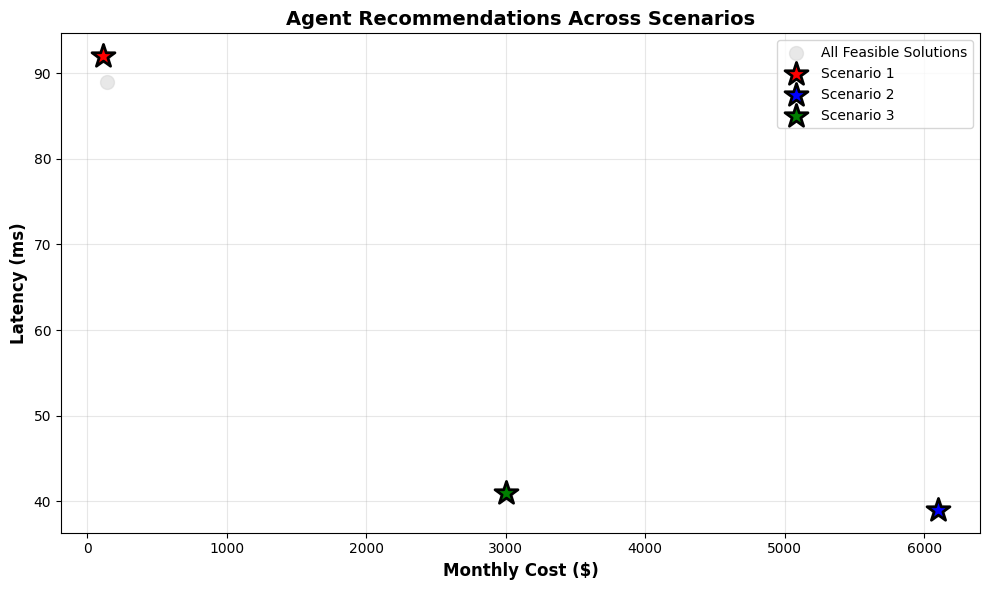


✓ Visualization saved as 'images/scenario_recommendations.png'


In [83]:
# Visualization showing recommended solutions for each scenario
fig, ax = plt.subplots(figsize=(10, 6))

# Background: feasible solutions
ax.scatter(feasible_df['monthly_cost'], feasible_df['latency_ms'],
           s=100, c='lightgray', alpha=0.5,
           label='All Feasible Solutions')

colors = ['red', 'blue', 'green']

for i, (scenario_name, result) in enumerate(zip(scenarios.keys(), results)):

    solution_row = feasible_df[
        (feasible_df['machine_type'] == result['Machine Type']) &
        (feasible_df['region'] == result['Region'])
    ].iloc[0]

    ax.scatter(solution_row['monthly_cost'],
               solution_row['latency_ms'],
               s=300,
               c=colors[i],
               marker='*',
               edgecolors='black',
               linewidth=2,
               label=scenario_name.split(':')[0],
               zorder=5)

ax.set_xlabel('Monthly Cost ($)', fontsize=12, fontweight='bold')
ax.set_ylabel('Latency (ms)', fontsize=12, fontweight='bold')
ax.set_title('Agent Recommendations Across Scenarios', fontsize=14, fontweight='bold')

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/scenario_recommendations.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Visualization saved as 'images/scenario_recommendations.png'")

### Part 2.5: Agent Explanation & Transparency

In [84]:
def generate_executive_summary(agent, recommendation_dict, feasible_df):

    solution = recommendation_dict['solution']
    scenario = recommendation_dict['scenario']

    summary = []
    summary.append("="*70)
    summary.append("EXECUTIVE DECISION BRIEF")
    summary.append("="*70)
    summary.append("")

    # 1. Recommendation
    summary.append("RECOMMENDED ACTION:")
    summary.append(f"  • Deploy: {solution['machine_type']}")
    summary.append(f"  • Region: {solution['region']}")
    summary.append("")

    # 2. Expected Outcomes
    summary.append("EXPECTED RESULTS:")
    summary.append(f"  • Monthly Cost: ${solution[agent.obj1_col]:.1f}")
    summary.append(f"  • Latency: {solution[agent.obj2_col]:.1f} ms")
    summary.append("")

    # 3. Why this decision
    summary.append("WHY THIS DECISION:")
    for reason in recommendation_dict['reasoning']:
        summary.append(f"  • {reason}")
    summary.append("")

    # 4. Alternatives
    summary.append("ALTERNATIVES CONSIDERED:")

    # Lowest cost option
    alt_cost = feasible_df.loc[feasible_df[agent.obj1_col].idxmin()]
    if alt_cost.name != solution.name:
        summary.append(f"  • Lowest Cost Option:")
        summary.append(f"    Cost=${alt_cost[agent.obj1_col]:.1f}, Latency={alt_cost[agent.obj2_col]:.1f}")
        summary.append("    Not chosen: higher latency")

    # Lowest latency option
    alt_latency = feasible_df.loc[feasible_df[agent.obj2_col].idxmin()]
    if alt_latency.name != solution.name:
        summary.append(f"  • Lowest Latency Option:")
        summary.append(f"    Cost=${alt_latency[agent.obj1_col]:.1f}, Latency={alt_latency[agent.obj2_col]:.1f}")
        summary.append("    Not chosen: significantly higher cost")

    summary.append("")

    # 5. Tradeoffs
    summary.append("TRADEOFFS:")

    best_cost = feasible_df[agent.obj1_col].min()
    best_latency = feasible_df[agent.obj2_col].min()

    cost_diff = solution[agent.obj1_col] - best_cost
    latency_diff = solution[agent.obj2_col] - best_latency

    if cost_diff > 0:
        summary.append(f"  • Paying +${cost_diff:.1f} above minimum cost")
    if latency_diff > 0:
        summary.append(f"  • Accepting +{latency_diff:.1f} ms above best latency")

    if cost_diff == 0 and latency_diff == 0:
        summary.append("  • Optimal on both dimensions")

    summary.append("")

    # 6. Risks
    summary.append("RISKS & LIMITATIONS:")
    summary.append("  • Based on synthetic cloud pricing data")
    summary.append("  • Does not include traffic variability or scaling behavior")
    summary.append("  • Assumes stable demand and workload patterns")
    summary.append("")

    # 7. Implementation
    summary.append("NEXT STEPS FOR IMPLEMENTATION:")
    summary.append("  1. Validate cost assumptions with cloud pricing tools")
    summary.append("  2. Run performance benchmarks")
    summary.append("  3. Deploy pilot test in selected region")
    summary.append("")

    summary.append("="*70)

    return "\n".join(summary)

# Test the executive summary
print("\n=== EXECUTIVE SUMMARY EXAMPLE ===\n")

test_scenario = list(scenarios.values())[0]
test_recommendation = agent.recommend(test_scenario)

print(generate_executive_summary(agent, test_recommendation, feasible_df))


=== EXECUTIVE SUMMARY EXAMPLE ===

EXECUTIVE DECISION BRIEF

RECOMMENDED ACTION:
  • Deploy: c2-standard-8
  • Region: us-east4

EXPECTED RESULTS:
  • Monthly Cost: $110.0
  • Latency: 92.0 ms

WHY THIS DECISION:
  • Cost priority → minimizing monthly cost

ALTERNATIVES CONSIDERED:
  • Lowest Latency Option:
    Cost=$6100.0, Latency=39.0
    Not chosen: significantly higher cost

TRADEOFFS:
  • Accepting +53.0 ms above best latency

RISKS & LIMITATIONS:
  • Based on synthetic cloud pricing data
  • Does not include traffic variability or scaling behavior
  • Assumes stable demand and workload patterns

NEXT STEPS FOR IMPLEMENTATION:
  1. Validate cost assumptions with cloud pricing tools
  2. Run performance benchmarks
  3. Deploy pilot test in selected region



In [85]:
def what_if_analysis(agent, feasible_df, base_scenario):

    print("\n=== WHAT-IF ANALYSIS ===\n")
    print("How would the recommendation change if priorities shifted?\n")

    #Base Case
    base_rec = agent.recommend(base_scenario)
    base_solution = base_rec['solution']

    print(f"BASE CASE ({base_scenario.get('priority')} priority):")
    print(f"  Machine: {base_solution['machine_type']}")
    print(f"  Region: {base_solution['region']}")
    print(f"  Cost: ${base_solution[agent.obj1_col]:.1f}")
    print(f"  Latency: {base_solution[agent.obj2_col]:.1f} ms\n")

    # Test alternative priorities
    priorities = ['cost', 'latency', 'balanced']

    for p in priorities:
        if p == base_scenario.get('priority'):
            continue

        alt_scenario = base_scenario.copy()
        alt_scenario['priority'] = p

        alt_rec = agent.recommend(alt_scenario)
        alt_sol = alt_rec['solution']

        print(f"IF priority = '{p}':")
        print(f"  Machine: {alt_sol['machine_type']}")
        print(f"  Region: {alt_sol['region']}")
        print(f"  Cost: ${alt_sol[agent.obj1_col]:.1f}")
        print(f"  Latency: {alt_sol[agent.obj2_col]:.1f} ms")

        cost_change = alt_sol[agent.obj1_col] - base_solution[agent.obj1_col]
        latency_change = alt_sol[agent.obj2_col] - base_solution[agent.obj2_col]

        print(f"  Impact: Cost {cost_change:+.1f}, Latency {latency_change:+.1f}\n")
        
# Run what-if analysis
base = list(scenarios.values())[2] 
what_if_analysis(agent, feasible_df, base)

print("Insight: Small latency improvements require disproportionately large cost increases.")


=== WHAT-IF ANALYSIS ===

How would the recommendation change if priorities shifted?

BASE CASE (balanced priority):
  Machine: m2-ultramem-208
  Region: us-central1
  Cost: $3000.0
  Latency: 41.0 ms

IF priority = 'cost':
  Machine: c2-standard-8
  Region: us-east4
  Cost: $110.0
  Latency: 92.0 ms
  Impact: Cost -2890.0, Latency +51.0

IF priority = 'latency':
  Machine: m2-ultramem-208
  Region: us-east1
  Cost: $6100.0
  Latency: 39.0 ms
  Impact: Cost +3100.0, Latency -2.0

Insight: Small latency improvements require disproportionately large cost increases.


=== VISUALIZING AGENT DECISION PROCESS ===


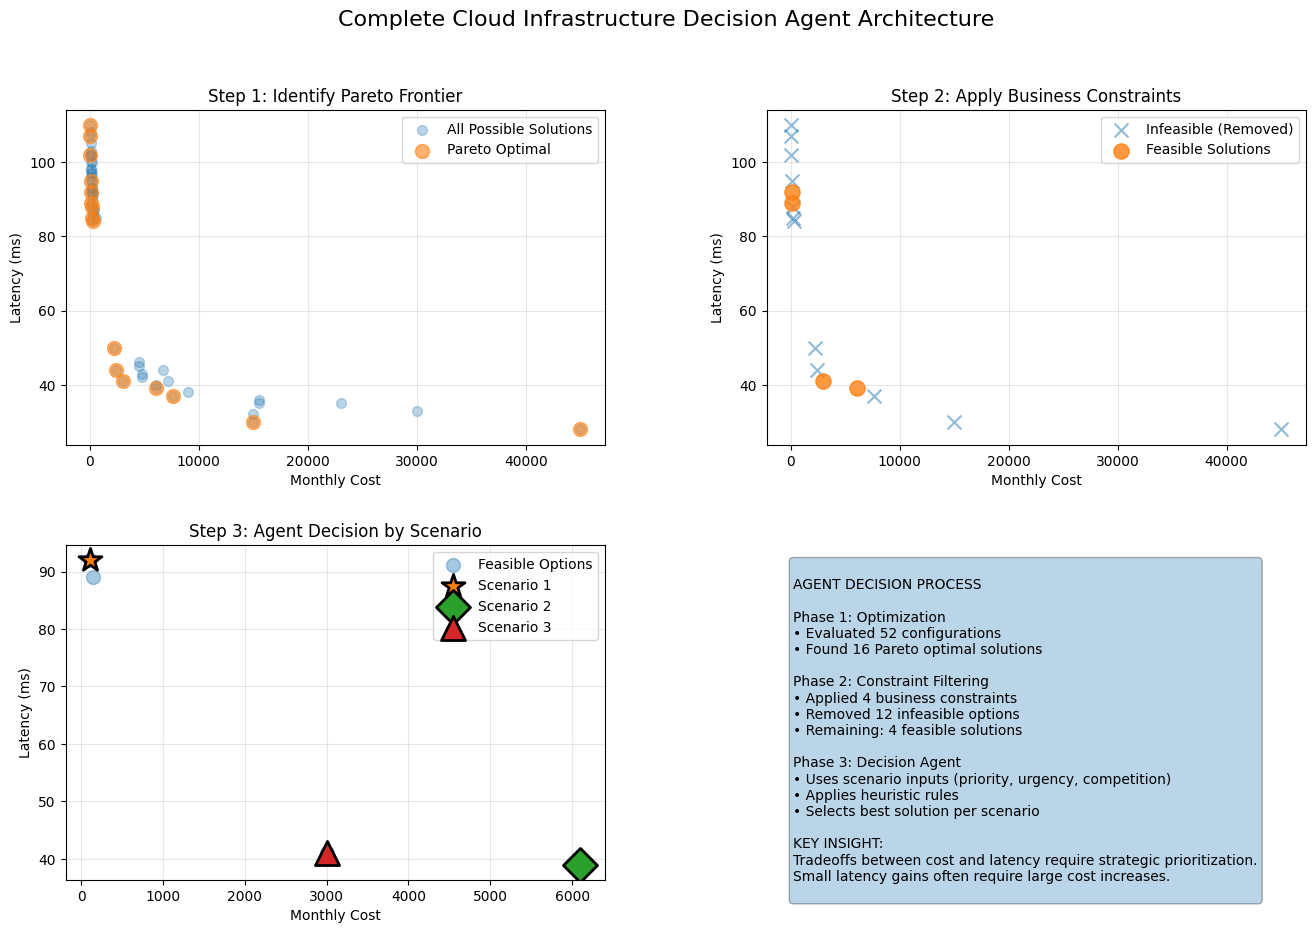

✓ Saved as images/agent_decision_process.png


In [86]:
print("=== VISUALIZING AGENT DECISION PROCESS ===")

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# PANEL 1: Pareto Frontier(top left)
ax1 = fig.add_subplot(gs[0, 0])

ax1.scatter(df['monthly_cost'], df['latency_ms'],
            s=50, alpha=0.3, label='All Possible Solutions')

ax1.scatter(pareto_df['monthly_cost'], pareto_df['latency_ms'],
            s=100, alpha=0.6, label='Pareto Optimal')

ax1.set_xlabel('Monthly Cost')
ax1.set_ylabel('Latency (ms)')
ax1.set_title('Step 1: Identify Pareto Frontier')
ax1.legend()
ax1.grid(True, alpha=0.3)

# PANEL 2: Constraint Filtering(top right)
ax2 = fig.add_subplot(gs[0, 1])

infeasible_df = pareto_df[~pareto_df.index.isin(feasible_df.index)]

if len(infeasible_df) > 0:
    ax2.scatter(infeasible_df['monthly_cost'], infeasible_df['latency_ms'],
                s=100, alpha=0.5, marker='x',
                label='Infeasible (Removed)')

ax2.scatter(feasible_df['monthly_cost'], feasible_df['latency_ms'],
            s=120, alpha=0.8, label='Feasible Solutions')

ax2.set_xlabel('Monthly Cost')
ax2.set_ylabel('Latency (ms)')
ax2.set_title('Step 2: Apply Business Constraints')
ax2.legend()
ax2.grid(True, alpha=0.3)

# PANEL 3: Scenario Decisions (bottom left)
ax3 = fig.add_subplot(gs[1, 0])

ax3.scatter(feasible_df['monthly_cost'], feasible_df['latency_ms'],
            s=100, alpha=0.4, label='Feasible Options')

markers = ['*', 'D', '^']

for i, (scenario_name, result) in enumerate(zip(scenarios.keys(), results)):
    solution_row = feasible_df[
        (feasible_df['machine_type'] == result['Machine Type']) &
        (feasible_df['region'] == result['Region'])
    ].iloc[0]

    short_name = scenario_name.split(':')[0]

    ax3.scatter(solution_row['monthly_cost'], solution_row['latency_ms'],
                s=300,
                marker=markers[i % len(markers)],
                edgecolors='black',
                linewidth=2,
                label=short_name,
                zorder=5)

ax3.set_xlabel('Monthly Cost')
ax3.set_ylabel('Latency (ms)')
ax3.set_title('Step 3: Agent Decision by Scenario')
ax3.legend()
ax3.grid(True, alpha=0.3)

# PANEL 4: Explanation Box (bottom right)
ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')

text = f"""
AGENT DECISION PROCESS

Phase 1: Optimization
• Evaluated {len(df)} configurations
• Found {len(pareto_df)} Pareto optimal solutions

Phase 2: Constraint Filtering
• Applied {len(constraints_df)} business constraints
• Removed {len(pareto_df) - len(feasible_df)} infeasible options
• Remaining: {len(feasible_df)} feasible solutions

Phase 3: Decision Agent
• Uses scenario inputs (priority, urgency, competition)
• Applies heuristic rules
• Selects best solution per scenario

KEY INSIGHT:
Tradeoffs between cost and latency require strategic prioritization.
Small latency gains often require large cost increases.
"""

ax4.text(0.05, 0.95, text,
         transform=ax4.transAxes,
         fontsize=10,
         verticalalignment='top',
         bbox=dict(boxstyle='round', alpha=0.3))

plt.suptitle('Complete Cloud Infrastructure Decision Agent Architecture', fontsize=16)

plt.savefig('images/agent_decision_process.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved as images/agent_decision_process.png")

### Part 2.6: Final Recommendation

In [87]:
print("=== FINAL RECOMMENDATION FOR CLOUD INFRASTRUCTURE STRATEGY ===\n")

current_business_scenario = {
    'priority': 'balanced',
    'urgency': 'medium',
    'competitive_pressure': 'high',
    'description': """
    The company is experiencing steady user growth and increased application demand, 
    requiring improved system performance while maintaining cost efficiency. 
    Rising cloud infrastructure expenses have become a concern, but competitive pressure 
    requires maintaining low latency to ensure strong user experience. 
    
    This scenario reflects a need to balance performance and cost while remaining 
    competitive in a performance-sensitive market.
    """
}

print("CURRENT BUSINESS CONTEXT:")
print(current_business_scenario['description'])
print()

=== FINAL RECOMMENDATION FOR CLOUD INFRASTRUCTURE STRATEGY ===

CURRENT BUSINESS CONTEXT:

    The company is experiencing steady user growth and increased application demand, 
    requiring improved system performance while maintaining cost efficiency. 
    Rising cloud infrastructure expenses have become a concern, but competitive pressure 
    requires maintaining low latency to ensure strong user experience. 
    
    This scenario reflects a need to balance performance and cost while remaining 
    competitive in a performance-sensitive market.
    



In [88]:
# Agent recommendation for current scenario
final_recommendation = agent.recommend(current_business_scenario)

# Generate comprehensive executive summary
final_executive_brief = generate_executive_summary(
    agent, final_recommendation, feasible_df
)

print(final_executive_brief)

EXECUTIVE DECISION BRIEF

RECOMMENDED ACTION:
  • Deploy: m2-ultramem-208
  • Region: us-central1

EXPECTED RESULTS:
  • Monthly Cost: $3000.0
  • Latency: 41.0 ms

WHY THIS DECISION:
  • Balanced strategy → normalized tradeoff between cost and latency

ALTERNATIVES CONSIDERED:
  • Lowest Cost Option:
    Cost=$110.0, Latency=92.0
    Not chosen: higher latency
  • Lowest Latency Option:
    Cost=$6100.0, Latency=39.0
    Not chosen: significantly higher cost

TRADEOFFS:
  • Paying +$2890.0 above minimum cost
  • Accepting +2.0 ms above best latency

RISKS & LIMITATIONS:
  • Based on synthetic cloud pricing data
  • Does not include traffic variability or scaling behavior
  • Assumes stable demand and workload patterns

NEXT STEPS FOR IMPLEMENTATION:
  1. Validate cost assumptions with cloud pricing tools
  2. Run performance benchmarks
  3. Deploy pilot test in selected region



=== FINAL EXECUTIVE SUMMARY VISUAL ===


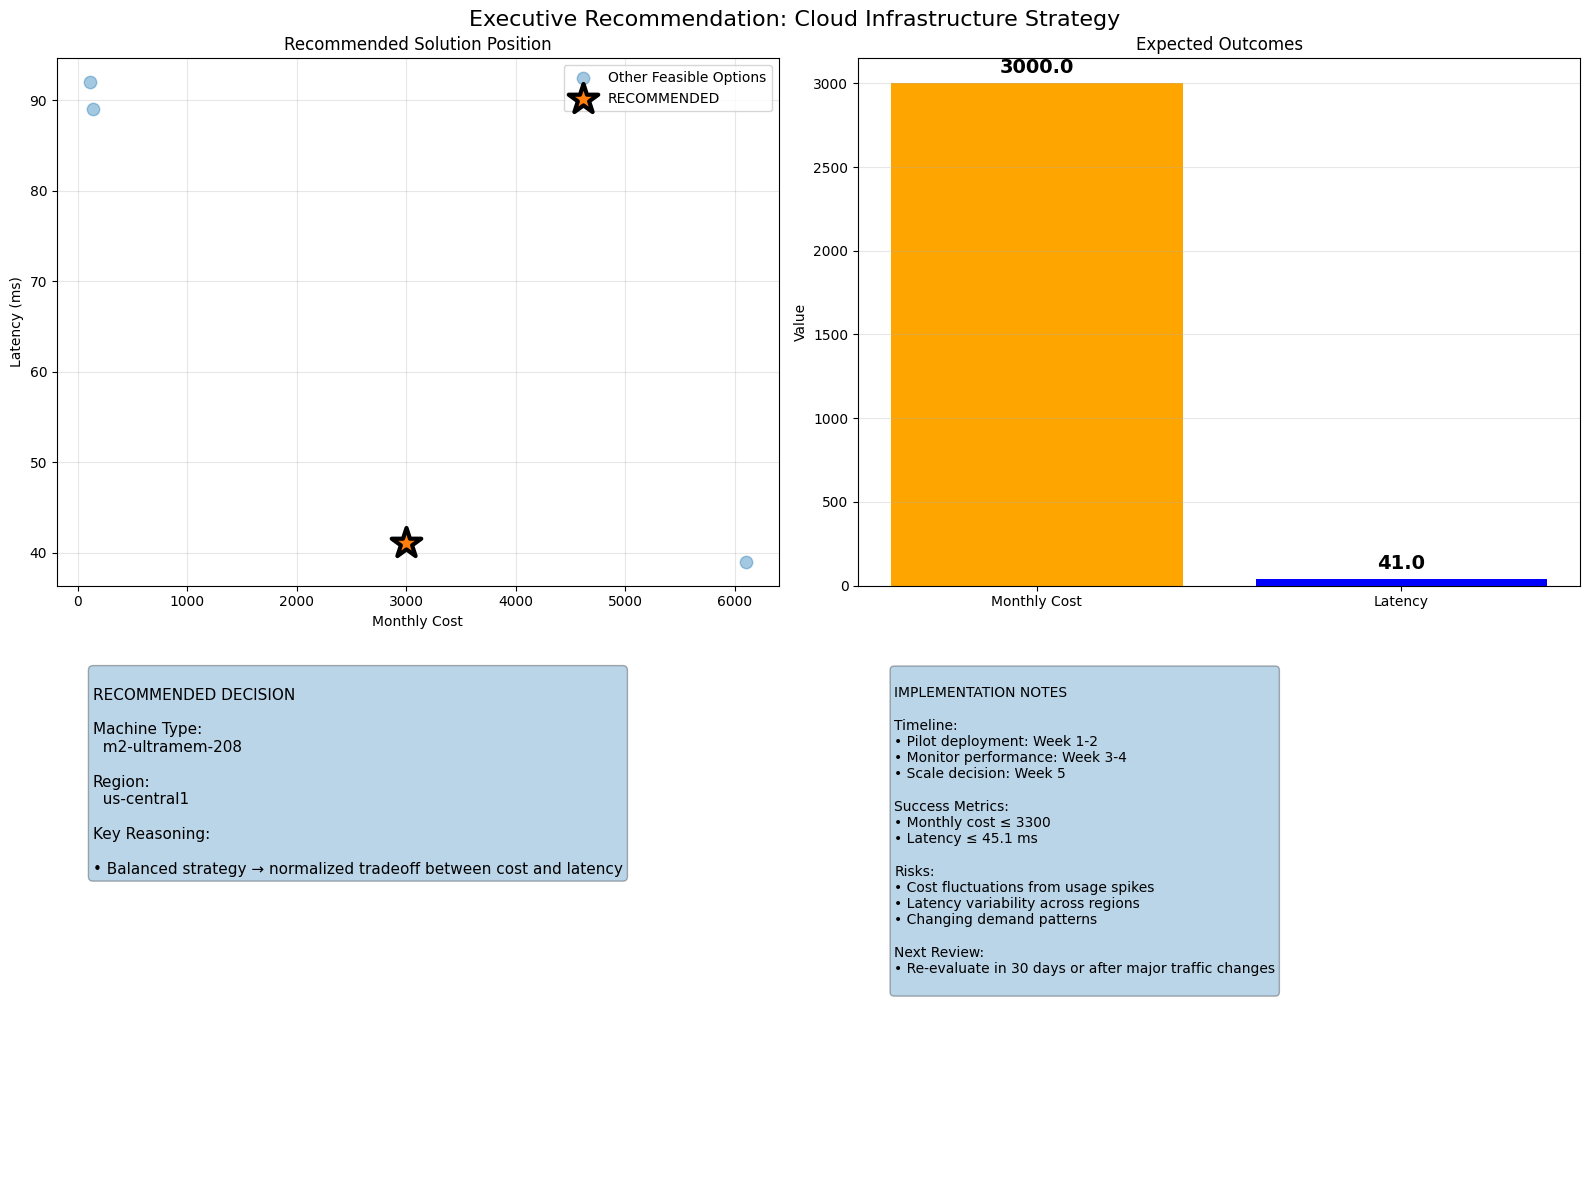


✓ Final recommendation summary saved as 'images/final_recommendation_summary.png'


In [89]:
print("=== FINAL EXECUTIVE SUMMARY VISUAL ===")

# Extract solution
solution = final_recommendation['solution']

# Create a single executive slide summarizing the recommendation
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Top Left: The tradeoff space with recommendation 
ax1.scatter(feasible_df['monthly_cost'], feasible_df['latency_ms'],
            s=80, alpha=0.4, label='Other Feasible Options')

ax1.scatter(solution['monthly_cost'], solution['latency_ms'],
            s=500, marker='*', edgecolors='black', linewidth=3,
            label='RECOMMENDED', zorder=5)

ax1.set_xlabel('Monthly Cost')
ax1.set_ylabel('Latency (ms)')
ax1.set_title('Recommended Solution Position')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Top Right: Bar chart comparing objectives
labels = ['Monthly Cost', 'Latency']
values = [solution['monthly_cost'], solution['latency_ms']]

ax2.bar(labels, values, color=['orange', 'blue'])

ax2.set_ylabel('Value')
ax2.set_title('Expected Outcomes')
ax2.grid(True, axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(values):
    ax2.text(i, v + (0.02 * max(values)), f"{v:.1f}", ha='center', fontsize=14, fontweight='bold')


# Bottom Left: Decision variables
ax3.axis('off')

decision_text = f"""
RECOMMENDED DECISION

Machine Type:
  {solution['machine_type']}

Region:
  {solution['region']}

Key Reasoning:
"""

for reason in final_recommendation['reasoning'][:3]:
    decision_text += f"\n• {reason}"

ax3.text(0.05, 0.95, decision_text,
         transform=ax3.transAxes,
         fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle='round', alpha=0.3))

# Bottom Right: Implementation notes
ax4.axis('off')

impl_text = f"""
IMPLEMENTATION NOTES

Timeline:
• Pilot deployment: Week 1-2
• Monitor performance: Week 3-4
• Scale decision: Week 5

Success Metrics:
• Monthly cost ≤ {solution['monthly_cost'] * 1.1:.0f}
• Latency ≤ {solution['latency_ms'] * 1.1:.1f} ms

Risks:
• Cost fluctuations from usage spikes
• Latency variability across regions
• Changing demand patterns

Next Review:
• Re-evaluate in 30 days or after major traffic changes
"""

ax4.text(0.05, 0.95, impl_text,
         transform=ax4.transAxes,
         fontsize=10,
         verticalalignment='top',
         bbox=dict(boxstyle='round', alpha=0.3))

# Title + Save
plt.suptitle('Executive Recommendation: Cloud Infrastructure Strategy',
             fontsize=16)

plt.tight_layout()
plt.savefig('images/final_recommendation_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Final recommendation summary saved as 'images/final_recommendation_summary.png'")

In [90]:
# Save the executive brief to a text file for easy sharing
with open('FINAL_RECOMMENDATION.txt', 'w', encoding='utf-8') as f:
    f.write(final_executive_brief)
    f.write("\n\n")
    f.write("="*70)
    f.write("\nGENERATED BY: Optimization-Based Decision Agent")
    f.write(f"\nDATE: {pd.Timestamp.now().strftime('%Y-%m-%d')}")
    f.write("\nSTUDENT: Naika Jean") 
    f.write("\nPROJECT: Cloud Infrastructure Optimization")
    f.write("\n" + "="*70)

print("✓ Recommendation saved to 'FINAL_RECOMMENDATION.txt'")

✓ Recommendation saved to 'FINAL_RECOMMENDATION.txt'


## Phase 2 Summary: Decision Agent
### Agent Architecture

This decision agent implements a three-stage architecture:

***Stage 1: Optimization (Phase 1)***

- Input: Cloud infrastructure configurations (machine type, region) with competing objectives (cost vs latency)
- Process: Pareto frontier computation
- Output: Set of all efficient tradeoff solutions

***Stage 2: Constraint Filtering (Part 2.1–2.2)***

- Input: Pareto frontier + real-world business constraints
- Process: Filtering based on feasibility rules (budget limits, performance thresholds, etc.)
- Output: Reduced set of implementable solutions

***Stage 3: Heuristic Selection (Part 2.3–2.6)***

- Input: Feasible solutions + business scenario context
- Process: Rule-based decision logic using priorities (cost, latency, balanced), urgency, and competition
- Output: Single recommended infrastructure configuration with explanation

### Key Features
- **Constraint-Aware**: Filters out solutions that violate cost or performance limits
- **Context-Sensitive**: Adjusts decisions based on business scenarios (ex: high traffic vs budget cuts)
- **Explainable**: Provides human-readable reasoning for every recommendation
- **Testable**: Evaluated across multiple realistic scenarios and what-if analyses

### Agent Decision Rules

The agent uses the following heuristic logic:

High urgency + high competition → prioritize latency

Rationale: Fast response time is critical for user experience under pressure
Priority-based decisions

1. If priority = cost → choose lowest-cost solution
2. If priority = latency → choose lowest-latency solution
3. If priority = balanced → use normalized tradeoff between cost and latency
Moderate urgency → bias toward latency

Rationale: Performance becomes more important when demand increases

Default (no clear priority) → equity strategy

Select solution with smallest gap between cost and latency


### Important Note on Visualization

The objective metrics (monthly cost and latency) are on very different scales (e.g., cost in thousands vs latency in milliseconds).
As a result, visual comparisons (such as bar charts) may appear skewed, with cost dominating the chart.

This is expected and does not indicate an error—interpretation should consider the difference in units and magnitude.

### Limitations
- Assumes constraints remain constant over time
- Uses rule-based heuristics rather than learned models
- Does not account for:
    - dynamic cloud pricing changes
    - regional outages or reliability differences
    - workload-specific performance variability
- Requires human oversight before real-world deployment

### Future Improvements
- Integrate machine learning for adaptive decision-making
- Incorporate real-time pricing and monitoring data
- Extend to more objectives (ex: reliability, scalability)
- Add uncertainty modeling for risk-aware decisions

In [91]:
import os

print("="*70)
print("FINAL PROJECT VERIFICATION")
print("="*70)

print("\n✓ Phase 1: Optimization Engine")
print(f"  - Analyzed {len(df)} solutions")
print(f"  - Identified {len(pareto_df)} Pareto optimal solutions")
print(f"  - Created visualizations")

print("\n✓ Phase 2: Decision Agent")
print(f"  - Applied business constraints")
print(f"  - Filtered to {len(feasible_df)} feasible solutions")
print(f"  - Tested across {len(scenarios)} scenarios")
print(f"  - Generated final recommendation")

print("\n✓ Documentation")
print("  - README.md updated")
print("  - Phase 2 summary included")
print("  - Executive explanation system completed")

print("\n✓ Deliverables Check")

files_created = [
    'optimization_engine.ipynb',
    'images/pareto_frontier_analysis.png',
    'images/feasible_region.png',
    'images/scenario_recommendations.png',
    'images/agent_decision_process.png',
    'images/final_recommendation_summary.png',
    'FINAL_RECOMMENDATION.txt',
    'README.md',
    'requirements.txt'
]

for file in files_created:
    status = "✓" if os.path.exists(file) else "✗"
    print(f"  {status} {file}")

print("\n" + "="*70)
print("PROJECT COMPLETE - READY FOR SUBMISSION")
print("="*70)

FINAL PROJECT VERIFICATION

✓ Phase 1: Optimization Engine
  - Analyzed 52 solutions
  - Identified 16 Pareto optimal solutions
  - Created visualizations

✓ Phase 2: Decision Agent
  - Applied business constraints
  - Filtered to 4 feasible solutions
  - Tested across 3 scenarios
  - Generated final recommendation

✓ Documentation
  - README.md updated
  - Phase 2 summary included
  - Executive explanation system completed

✓ Deliverables Check
  ✓ optimization_engine.ipynb
  ✓ images/pareto_frontier_analysis.png
  ✓ images/feasible_region.png
  ✓ images/scenario_recommendations.png
  ✓ images/agent_decision_process.png
  ✓ images/final_recommendation_summary.png
  ✓ FINAL_RECOMMENDATION.txt
  ✓ README.md
  ✓ requirements.txt

PROJECT COMPLETE - READY FOR SUBMISSION
